In [ ]:
import zstandard as zstd

path = "data/raw/lichess_mini.pgn.zst"

with open(path, "rb") as fh:
    dctx = zstd.ZstdDecompressor()
    with dctx.stream_reader(fh) as reader:
        text = reader.read(10_000).decode("utf-8")

print(text)

[Event "Rated Blitz tournament https://lichess.org/tournament/WyLZ5r0n"]
[Site "https://lichess.org/HoJqFz7k"]
[White "t1r33"]
[Black "mashi"]
[Result "0-1"]
[UTCDate "2015.12.31"]
[UTCTime "23:00:03"]
[WhiteElo "1305"]
[BlackElo "1321"]
[WhiteRatingDiff "-13"]
[BlackRatingDiff "+14"]
[ECO "?"]
[Opening "?"]
[TimeControl "300+0"]
[Termination "Abandoned"]

 0-1

[Event "Rated Blitz tournament https://lichess.org/tournament/WyLZ5r0n"]
[Site "https://lichess.org/FYTW1fa0"]
[White "genibo77"]
[Black "skeith73"]
[Result "0-1"]
[UTCDate "2015.12.31"]
[UTCTime "23:00:03"]
[WhiteElo "1805"]
[BlackElo "1628"]
[WhiteRatingDiff "-17"]
[BlackRatingDiff "+17"]
[ECO "?"]
[Opening "?"]
[TimeControl "300+0"]
[Termination "Abandoned"]

 0-1

[Event "Rated Blitz tournament https://lichess.org/tournament/WyLZ5r0n"]
[Site "https://lichess.org/ocl40XzA"]
[White "herrmaa"]
[Black "Yory21"]
[Result "0-1"]
[UTCDate "2015.12.31"]
[UTCTime "23:00:03"]
[WhiteElo "1598"]
[BlackElo "1609"]
[WhiteRatingDiff "-11"]

In [ ]:
import zstandard as zstd
import re
import os
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def is_classical(tc: str) -> bool:
    """Classical: base time >= 600 seconds."""
    if not tc or tc == "-":
        return False
    try:
        base = int(tc.split("+")[0])
        return base >= 600
    except ValueError:
        return False

def count_moves(moves_str: str) -> int:
    """Count number of plies (half-moves) in a move string."""
    tokens = moves_str.split()
    tokens = [t for t in tokens if not re.match(r'^\d+\.', t)]
    tokens = [t for t in tokens if t not in {"1-0", "0-1", "1/2-1/2", "*"}]
    return len(tokens)

def parse_elo(val: str) -> int:
    """Parse Elo, return 0 for missing or unknown values."""
    try:
        return int(val)
    except (ValueError, TypeError):
        return 0

path = "data/raw/lichess_db_standard_rated_2016-01.pgn.zst"
file_size = os.path.getsize(path)

total_games   = 0
abandoned     = 0
not_classical = 0
too_short     = 0

# for qualifying games (classical + 10 moves): store min elo of both players
qualifying_min_elos = []

# parsing state
headers   = {}
moves_str = ""
in_moves  = False

with open(path, "rb") as fh:
    dctx = zstd.ZstdDecompressor()
    with dctx.stream_reader(fh) as reader:
        buffer = ""

        with tqdm(
            total=file_size,
            unit="B",
            unit_scale=True,
            unit_divisor=1024,
            desc="Scanning",
            bar_format="{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} "
                       "[{elapsed}<{remaining}, {rate_fmt}] — {postfix}",
        ) as pbar:

            while True:
                chunk = reader.read(1 << 20)
                if not chunk:
                    break

                pbar.update(fh.tell() - pbar.n)
                buffer += chunk.decode("utf-8", errors="replace")
                lines   = buffer.split("\n")
                buffer  = lines[-1]

                for line in lines[:-1]:
                    line = line.strip()

                    if line.startswith("["):
                        if in_moves and moves_str.strip():
                            total_games += 1
                            tc      = headers.get("TimeControl", "")
                            welo    = parse_elo(headers.get("WhiteElo", "0"))
                            belo    = parse_elo(headers.get("BlackElo", "0"))
                            n_moves = count_moves(moves_str)

                            if n_moves < 2:
                                abandoned += 1
                            elif not is_classical(tc):
                                not_classical += 1
                            elif n_moves < 20:
                                too_short += 1
                            else:
                                # qualifying game — store min elo of both players
                                qualifying_min_elos.append(min(welo, belo))

                            if total_games % 1000 == 0:
                                pbar.set_postfix({
                                    "games": f"{total_games:,}",
                                    "qualifying": f"{len(qualifying_min_elos):,}",
                                }, refresh=False)

                        m = re.match(r'\[(\w+)\s+"(.*)"\]', line)
                        if m:
                            if m.group(1) == "Event":
                                headers   = {}
                                moves_str = ""
                                in_moves  = False
                            headers[m.group(1)] = m.group(2)

                    elif line and not line.startswith("["):
                        in_moves = True
                        moves_str += " " + line

print(f"Total games seen:          {total_games:>10,}")
print(f"  Abandoned (no moves):    {abandoned:>10,}")
print(f"  Not classical TC:        {not_classical:>10,}")
print(f"  Too short (< 10 moves):  {too_short:>10,}")
print(f"  Qualifying (classical,   {len(qualifying_min_elos):>10,}")
print(f"  10+ moves, any Elo):")

Scanning:   0%|          | 0.00/831M [00:00<?, ?B/s] — 

Total games seen:           4,770,356
  Abandoned (no moves):        25,723
  Not classical TC:         3,943,375
  Too short (< 10 moves):      46,969
  Qualifying (classical,      754,289
  10+ moves, any Elo):


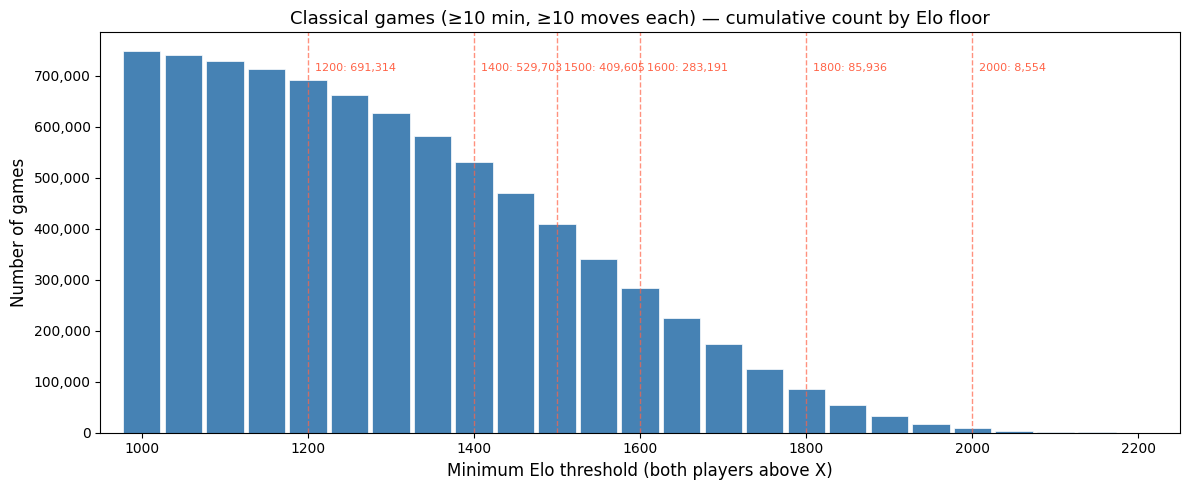

In [10]:
min_elos = np.array(qualifying_min_elos)

# x-axis: Elo thresholds from 1000 to 2200 in steps of 50
thresholds = np.arange(1000, 2201, 50)
counts     = [np.sum(min_elos >= t) for t in thresholds]

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(thresholds, counts, width=45, color="steelblue", edgecolor="white", linewidth=0.5)

# annotate a few key thresholds
for t in [1200, 1400, 1500, 1600, 1800, 2000]:
    n = int(np.sum(min_elos >= t))
    ax.axvline(t, color="tomato", linewidth=1, linestyle="--", alpha=0.7)
    ax.text(t + 8, max(counts) * 0.97, f"{t}: {n:,}",
            color="tomato", fontsize=8, va="top")

ax.set_xlabel("Minimum Elo threshold (both players above X)", fontsize=12)
ax.set_ylabel("Number of games", fontsize=12)
ax.set_title("Classical games (≥10 min, ≥10 moves each) — cumulative count by Elo floor",
             fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(950, 2250)

plt.tight_layout()
plt.show()

In [ ]:
import pyarrow.parquet as pq

table = pq.read_table("data/processed/dataset_mini_moves.parquet")
df = table.to_pandas()

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nToken length stats:")
print(df["n_tokens"].describe())
print(f"\nFirst game:")
print(f"  white_elo: {df['white_elo'][0]}")
print(f"  black_elo: {df['black_elo'][0]}")
print(f"  result:    {df['result'][0]}")
print(f"  n_tokens:  {df['n_tokens'][0]}")
print(f"  ids[:8]:   {list(df['input_ids'][0])[:8]}")
print(f"  scalars[:8]: {[round(s,1) for s in df['scalars'][0][:8]]}")

Shape: (23, 8)

Columns: ['game_id', 'white_elo', 'black_elo', 'result', 'n_tokens', 'input_ids', 'scalars', 'scalar_mask']

Token length stats:
count     23.000000
mean     181.391304
std       91.549658
min       50.000000
25%      116.000000
50%      169.000000
75%      232.500000
max      410.000000
Name: n_tokens, dtype: float64

First game:
  white_elo: 1406
  black_elo: 1434
  result:    -1.0
  n_tokens:  129
  ids[:8]:   [np.int8(1), np.int8(3), np.int8(4), np.int8(5), np.int8(15), np.int8(22), np.int8(15), np.int8(23)]
  scalars[:8]: [np.float32(0.0), np.float32(1406.0), np.float32(1434.0), np.float32(-1.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]


In [1]:
import pyarrow.parquet as pq
import numpy as np

table = pq.read_table("data/processed/dataset_mini_moves.parquet")
df = table.to_pandas()

# check token id range
all_ids = [id for ids in df["input_ids"] for id in ids]
print(f"Token id range: {min(all_ids)} to {max(all_ids)}")
print(f"Vocab size: 64")
print(f"Any ids >= 64? {any(i >= 64 for i in all_ids)}")
print(f"Random loss expected: {np.log(64):.4f}")

Token id range: 1 to 33
Vocab size: 64
Any ids >= 64? False
Random loss expected: 4.1589


In [2]:
import torch
import torch.nn.functional as F

# what loss do we expect for uniform random predictions over 64 tokens?
logits = torch.zeros(1, 64)  # uniform logits
target = torch.tensor([15])  # any valid token
loss = F.cross_entropy(logits, target)
print(f"Uniform logits loss: {loss:.4f}")  # should be ln(64) = 4.16

# what about the model's actual logits?
from model import ChessGPT, ChessGPTConfig
config = ChessGPTConfig.debug()
model = ChessGPT(config)
model.eval()

batch = next(iter(__import__('torch').utils.data.DataLoader(
    __import__('data.dataset', fromlist=['ChessDataset']).ChessDataset(
        'data/processed/dataset_mini_moves.parquet'), batch_size=2)))

with torch.no_grad():
    logits, loss = model(batch['input_ids'], batch['targets'])
    print(f"Model loss: {loss:.4f}")
    print(f"Logits mean: {logits.mean():.4f}")
    print(f"Logits std:  {logits.std():.4f}")
    print(f"Logits min:  {logits.min():.4f}")
    print(f"Logits max:  {logits.max():.4f}")

Uniform logits loss: 4.1589
ChessGPT: 0.13M parameters
Model loss: 4.1831
Logits mean: 0.0062
Logits std:  0.1953
Logits min:  -0.5113
Logits max:  1.3675


In [ ]:
import pyarrow.parquet as pq

# ── Vocabulary ────────────────────────────────────────────────────────────

CONTROL  = ["[PAD]", "[WIN]", "[DRAW]", "[LOSS]", "[GAME_END]"]
PIECES   = ["N", "B", "R", "Q", "K"]
FILES    = ["a", "b", "c", "d", "e", "f", "g", "h"]
RANKS    = ["1", "2", "3", "4", "5", "6", "7", "8"]
SPECIALS = ["O-O-O", "O-O", "x", "+", "#", "[PROMOTION]"]

vocab    = CONTROL + PIECES + FILES + RANKS + SPECIALS
ID2TOKEN = {i: tok for i, tok in enumerate(vocab)}

# ── Load and sample ───────────────────────────────────────────────────────

df  = pq.read_table("data/processed/dataset_moves.parquet").to_pandas()
row = df.sample(1).iloc[0]

ids    = list(row["input_ids"])
tokens = [ID2TOKEN[i] for i in ids]

# ── Print ─────────────────────────────────────────────────────────────────

print(f"white_elo : {row['white_elo']}   black_elo : {row['black_elo']}   result : {ID2TOKEN[row['result']]}   n_tokens : {row['n_tokens']}")
print()
print("Tokens :", " ".join(tokens[:80]))
print()
print(f"{'i':<4} {'token':<12} {'id':<4}")
print("-" * 22)
for i in range(20):
    print(f"{i:<4} {tokens[i]:<12} {ids[i]:<4}")

white_elo : 1555   black_elo : 1520   result : -1.0   n_tokens : 149

Tokens : [GAME_START] [WHITE_ELO] [BLACK_ELO] [RESULT] d 4 d 5 c 4 e 6 N c 3 N c 6 N f 3 B b 4 B d 2 N f 6 N N x e 5 N d 7 N x e 5 d 5 d 5 Q a 4 + N c 6 B b 5 a 5 B x c 6 + c 6 O-O O-O a 3 B d 6 R c 1 Q Q x c 6

i    token      id   scalar
--------------------------------
0    [GAME_START] 1    
1    [WHITE_ELO] 3    1555.0
2    [BLACK_ELO] 4    1520.0
3    [RESULT]   5    -1.0
4    d          14   
5    4          22   
6    d          14   
7    5          23   
8    c          13   
9    4          22   
10   e          15   
11   6          24   
12   N          6    
13   c          13   
14   3          21   
15   N          6    
16   c          13   
17   6          24   
18   N          6    
19   f          16   
